In [15]:
# Abrir xlsx en la carpeta Data
import pandas as pd
data = pd.read_excel('Data/AA_V2.xlsx')
data.head()

,COL_000,COL_001,COL_002,COL_003,COL_004,Lubricant,COL_006,Observation Type,Observation Date,COL_009,...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
0,COM_0001,ASS_0001,FLO_0001,LOC_0001,COM_0001,Terpel MAXTER PROGRESA 15W-40 API CI-4 PLUS,CON_0001,Fluid Analysis,2025-01-26,OBS_0001,...,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COM_0002,ASS_0002,FLO_0002,LOC_0001,COM_0002,Terpel MAXTER PROGRESA 15W-40 API CI-4 PLUS,CON_0002,Fluid Analysis,2025-01-26,OBS_0002,...,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COM_0003,ASS_0003,FLO_0002,LOC_0001,COM_0002,Terpel MAXTER PROGRESA 15W-40 API CI-4 PLUS,CON_0003,Fluid Analysis,2025-01-25,OBS_0003,...,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COM_0004,ASS_0004,FLO_0003,LOC_0001,COM_0003,Terpel MAXTER PROGRESA 15W-40 API CI-4 PLUS,CON_0004,Fluid Analysis,2025-01-25,OBS_0004,...,0.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,COM_0005,ASS_0004,FLO_0003,LOC_0001,COM_0003,Terpel MAXTER PROGRESA 15W-40 API CI-4 PLUS,CON_0005,Fluid Analysis,2025-01-25,OBS_0005,...,1.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Parte I: Calidad de datos

* Descripcion general de los datos
* De donde vienen
* Inpeccion de calidad (Basado en lo que haciamos en ETL)

# Parte II: Técnicas de limpieza

* Rango de los datos y validez
* Faltantes y coherencia de los tipos de datos
* Outliers y justificar si se deben o no eliminar o imputar
* Correlaciones entre las variables

Ante los hallazgos de esta etapa se deben plantear alternativas de tratamiento (Eliminación o imputación)

# Parte III: Entendimiento de los datos

* Descripción de estadisticas basicas
* Análisis de distribucion de los datos
* Distribuciones frente a las categorias de la variable objetivo
* Feature importance
* Adición de nueva información

In [25]:
data.shape

(4297, 66)

In [22]:
# Renombrar algunas columnas
data = data.rename(columns={'COL_000': 'ID_COMPONENTE', 'COL_001': 'ASSET_ID', 'COL_002': 'FLOTA', 'COL_003': 'CARPETA', 
                            'COL_004': 'PERFIL', 'COL_006': 'CONN_CODE', 'COL_009': 'OBSERVATION_CODE'})

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4297 entries, 0 to 4296
Data columns (total 66 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ID_COMPONENTE                    4297 non-null   object        
 1   ASSET_ID                         4297 non-null   object        
 2   FLOTA                            4297 non-null   object        
 3   CARPETA                          4297 non-null   object        
 4   PERFIL                           4297 non-null   object        
 5   Lubricant                        4297 non-null   object        
 6   CONN_CODE                        4297 non-null   object        
 7   Observation Type                 4297 non-null   object        
 8   Observation Date                 4297 non-null   datetime64[ns]
 9   OBSERVATION_CODE                 4297 non-null   object        
 10  Meter Reading                    4297 non-null   float64    

In [16]:
data.describe()

,Observation Date,Meter Reading,All Time Meter Reading,Component Age,Observation Interval,days,Lube Age,Live,Added,Reviewed,...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
count,4297,4297.000000,4297.00000,4297.000000,4273.000000,4273.000000,114.000000,4237.000000,4297.0,4284,...,4221.000000,27.0,26.000000,28.000000,26.000000,28.000000,28.000000,28.000000,0.0,0.0
mean,2022-10-03 23:21:47.796136704,37718.445041,40323.21411,8605.917747,246.894533,16.265621,7222.688421,8679.136592,0.0,2022-10-11 15:30:56.689075712,...,1.099069,0.0,48.443077,1751.428571,106.584615,914.571429,21.607143,9.453571,NaN,NaN
min,2020-01-02 00:00:00,0.000000,0.00000,0.000000,0.000000,1.000000,285.490000,0.000000,0.0,2020-01-06 20:53:55,...,0.000000,0.0,45.700000,1400.000000,106.100000,605.000000,20.000000,8.200000,NaN,NaN
25%,2021-08-07 00:00:00,15113.480000,17012.62000,3712.030000,100.030000,7.000000,4116.575000,3853.400000,0.0,2021-08-10 13:44:58.500000,...,0.000000,0.0,47.637500,1630.000000,106.400000,790.250000,20.000000,8.875000,NaN,NaN
50%,2022-11-05 00:00:00,39790.300000,42576.53000,7442.050000,195.100000,13.000000,7426.295000,7477.100000,0.0,2022-11-09 10:08:24.500000,...,0.780000,0.0,48.775000,1750.000000,106.650000,897.000000,20.000000,9.650000,NaN,NaN
75%,2024-01-08 00:00:00,59400.140000,61160.00000,11850.940000,316.130000,22.000000,10378.597500,11835.370000,0.0,2024-01-22 08:36:05,...,1.120000,0.0,49.315000,1880.000000,106.775000,992.000000,20.000000,10.100000,NaN,NaN
max,2025-01-26 00:00:00,86467.570000,88527.24000,64709.850000,13231.070000,152.000000,16105.060000,64709.850000,0.0,2025-01-27 20:23:15,...,60.320000,0.0,50.180000,2000.000000,107.000000,1340.000000,33.000000,10.500000,NaN,NaN
std,NaN,24265.299867,24727.10970,7865.818600,407.557769,15.205517,3579.832924,7848.997992,0.0,NaN,...,2.094020,0.0,1.214311,171.047195,0.242804,184.793865,3.993878,0.705262,NaN,NaN


<Axes: >

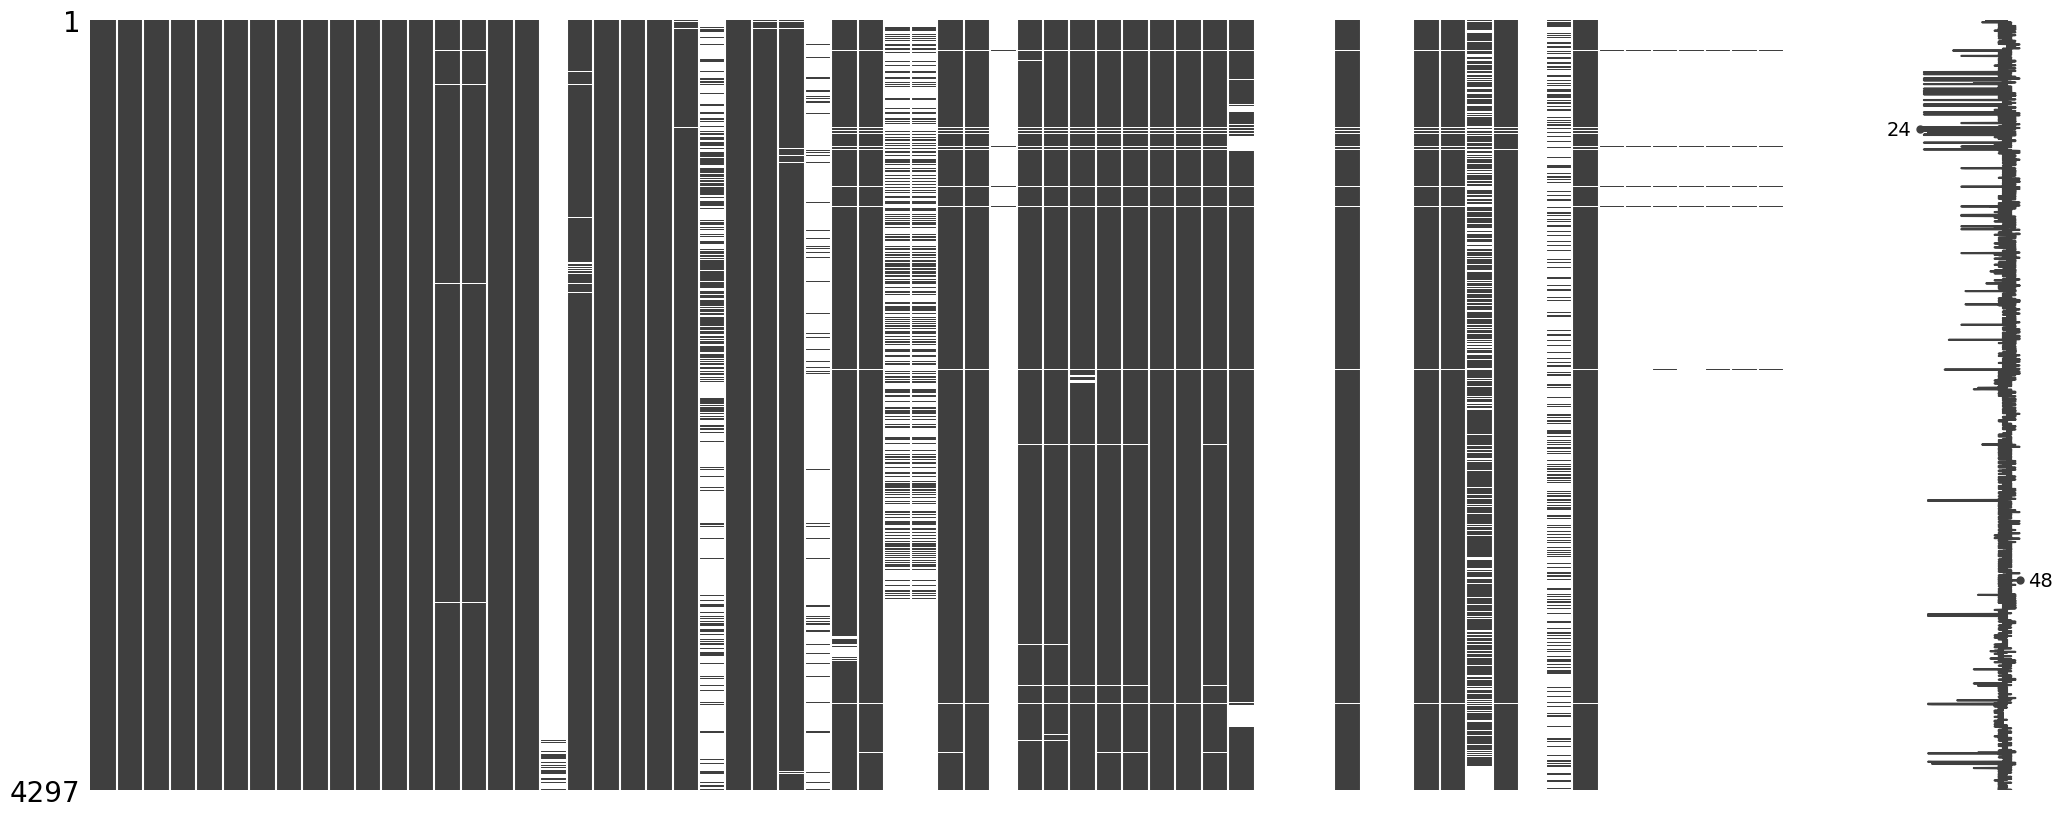

In [21]:
import missingno as msno
msno.matrix(data)
